***
# Final Project - PFDA 2024/2025
***
### Objetive: 
Write a Nootebook that demonstrate that you, can perform data analysis on some data. I will allow a lot of flexibility in this project, so that you can use it as an opportunity to do something thta is usefull for your work.
***
##### Steps:
1. StationDetail.csv was used as data base for this project;
1. Clean and normalise the data before doing analysis;
***

## Step 1: Load the Data

In [1]:
import os

# Check the current working directory
print("Current working directory:", os.getcwd())

# List the files in the current directory
print("Files in the current directory:", os.listdir())

Current working directory: c:\Users\gusgo\OneDrive - Atlantic TU\PFDA\project
Files in the current directory: ['project.ipynb', 'StationDetail.csv']


In [2]:
import pandas as pd

# Define the file path
file_path = 'StationDetail.csv'

In [3]:
# Try to load the data
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully.")
    # Display the first few rows of the dataframe
    display(df.head())
except FileNotFoundError:
    print(f"File not found: {file_path}")
except pd.errors.EmptyDataError:
    print(f"No data: {file_path}")
except pd.errors.ParserError:
    print(f"Parsing error: {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

File loaded successfully.


,county,station name,name,height(m),easting,northing,latitude,longitude,open year,close year
0,Antrim,5880,LH_RATHLIN_WEST,10,309200,451800,55.30083,-6.28028,2000,(null)
1,Carlow,4415,TULLOW (Waterworks),76,284700,173400,52.80528,-6.74306,1985,(null)
2,Carlow,2414,BORRIS G.S.,85,272400,150700,52.60278,-6.93056,1944,1991
3,Carlow,1214,CARLOW (SUGAR FACTORY),58,272200,178400,52.85139,-6.92778,1953,1960
4,Carlow,115,HACKETSTOWN RECTORY,182,297600,180500,52.86667,-6.55000,1910,1944


## Step 2: Clean and Normalize the Data

In [4]:
import pandas as pd

# Load the data

weatherdata = pd.read_csv('StationDetail.csv', delimiter=',')  # read the data from the csv file

# Display the first few rows of the dataframe
weatherdata.head()

,county,station name,name,height(m),easting,northing,latitude,longitude,open year,close year
0,Antrim,5880,LH_RATHLIN_WEST,10,309200,451800,55.30083,-6.28028,2000,(null)
1,Carlow,4415,TULLOW (Waterworks),76,284700,173400,52.80528,-6.74306,1985,(null)
2,Carlow,2414,BORRIS G.S.,85,272400,150700,52.60278,-6.93056,1944,1991
3,Carlow,1214,CARLOW (SUGAR FACTORY),58,272200,178400,52.85139,-6.92778,1953,1960
4,Carlow,115,HACKETSTOWN RECTORY,182,297600,180500,52.86667,-6.55000,1910,1944


In [5]:
weatherdata = weatherdata.rename(columns={
    'county': 'County',
    'station name': 'Station Number',
    'name': 'Station Name',
    'height(m)': 'Height(m)',
    'easting': 'Easting',
    'northing': 'Northing',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'open year': 'Open Year',
    'close year': 'Close Year'
})
weatherdata.head()

,County,Station Number,Station Name,Height(m),Easting,Northing,Latitude,Longitude,Open Year,Close Year
0,Antrim,5880,LH_RATHLIN_WEST,10,309200,451800,55.30083,-6.28028,2000,(null)
1,Carlow,4415,TULLOW (Waterworks),76,284700,173400,52.80528,-6.74306,1985,(null)
2,Carlow,2414,BORRIS G.S.,85,272400,150700,52.60278,-6.93056,1944,1991
3,Carlow,1214,CARLOW (SUGAR FACTORY),58,272200,178400,52.85139,-6.92778,1953,1960
4,Carlow,115,HACKETSTOWN RECTORY,182,297600,180500,52.86667,-6.55000,1910,1944


In [6]:
# Check for missing values
print("Missing values per column:")
print(weatherdata.isnull().sum())

# Check for duplicates
print("Number of duplicate rows:")
print(weatherdata.duplicated().sum())

# Check data types
print("Data types of columns:")
print(weatherdata.dtypes)

Missing values per column:
County            0
Station Number    0
Station Name      0
Height(m)         0
Easting           0
Northing          0
Latitude          0
Longitude         0
Open Year         0
Close Year        0
dtype: int64
Number of duplicate rows:
0
Data types of columns:
County             object
Station Number      int64
Station Name       object
Height(m)           int64
Easting             int64
Northing            int64
Latitude          float64
Longitude         float64
Open Year          object
Close Year         object
dtype: object


## Step 3: Analyze Height(m)

Mean height: 88.02 m
Percentage of time heights are within operational range: 18.77%


C:\Users\gusgo\AppData\Local\Temp\ipykernel_4204\1907730759.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean_height = weatherdata['Height(m)'].resample('M').mean()


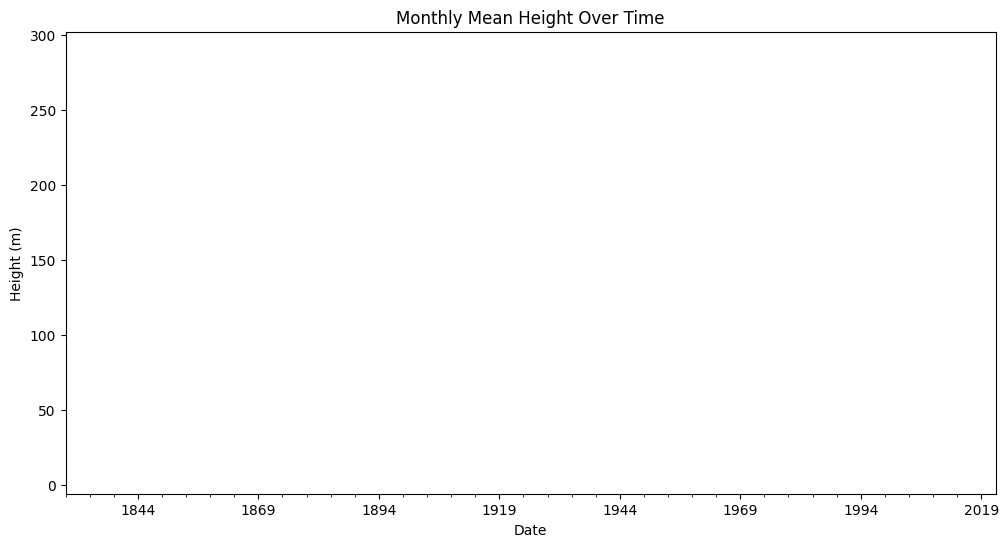

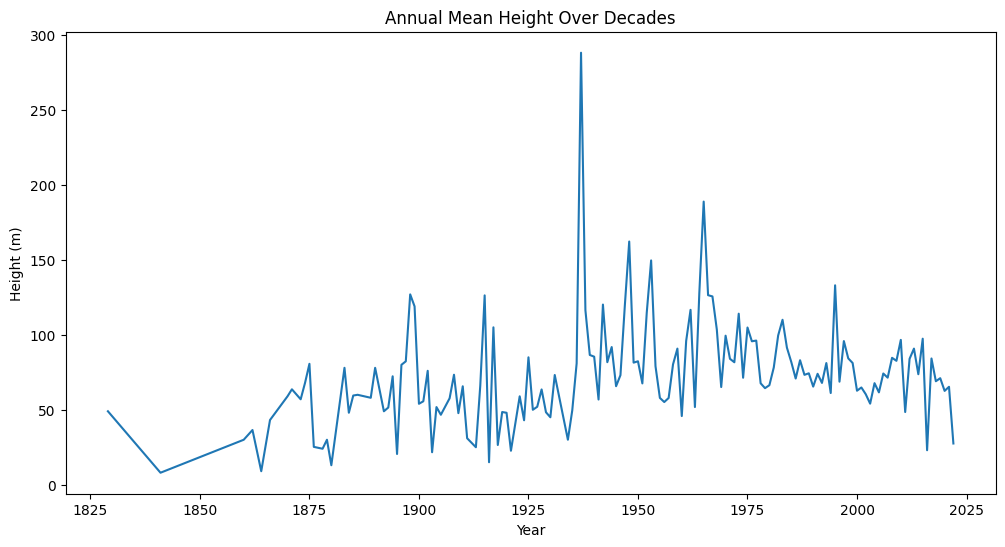

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mean height
mean_height = weatherdata['Height(m)'].mean()
print(f"Mean height: {mean_height:.2f} m")

# Height ranges
min_operational_height = 3.0  # Example minimum operational height in m
max_operational_height = 25.0  # Example maximum operational height in m
operational_heights = weatherdata[(weatherdata['Height(m)'] >= min_operational_height) & (weatherdata['Height(m)'] <= max_operational_height)]
print(f"Percentage of time heights are within operational range: {len(operational_heights) / len(weatherdata) * 100:.2f}%")

# Create a 'date' column based on 'Open Year' for demonstration purposes
weatherdata['date'] = pd.to_datetime(weatherdata['Open Year'], errors='coerce')
weatherdata.set_index('date', inplace=True)

# Height trends over time
monthly_mean_height = weatherdata['Height(m)'].resample('M').mean()

plt.figure(figsize=(12, 6))
monthly_mean_height.plot()
plt.title('Monthly Mean Height Over Time')
plt.xlabel('Date')
plt.ylabel('Height (m)')
plt.show()

# Height trends over decades
weatherdata['year'] = weatherdata.index.year
annual_mean_height = weatherdata.groupby('year')['Height(m)'].mean()

plt.figure(figsize=(12, 6))
annual_mean_height.plot()
plt.title('Annual Mean Height Over Decades')
plt.xlabel('Year')
plt.ylabel('Height (m)')
plt.show()

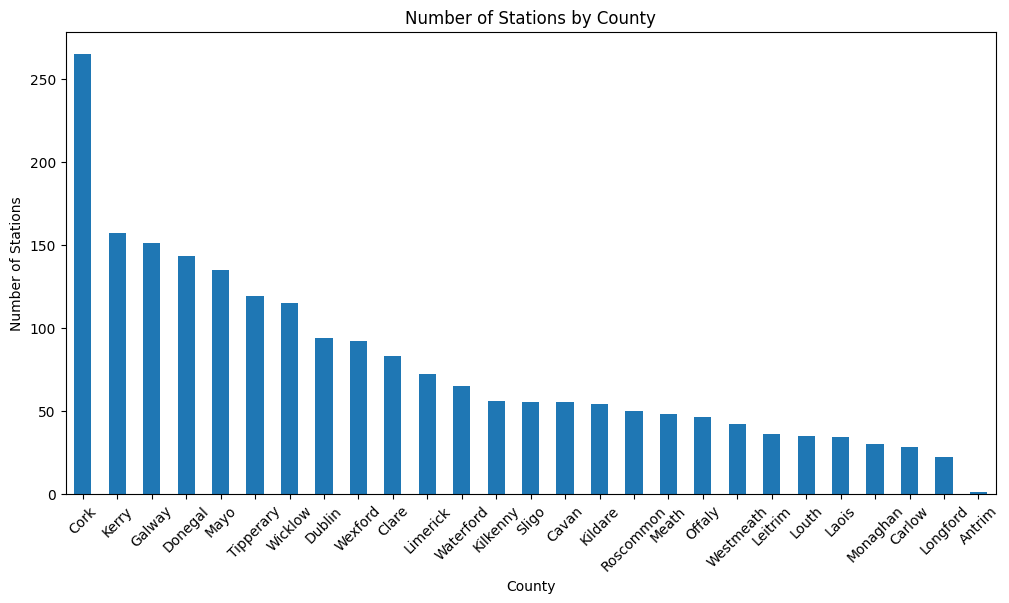

In [10]:
# Count the number of stations by county
stations_by_county = df['county'].value_counts()

# Plot the number of stations by county
plt.figure(figsize=(12, 6))
stations_by_county.plot(kind='bar')
plt.title('Number of Stations by County')
plt.xlabel('County')
plt.ylabel('Number of Stations')
plt.xticks(rotation=45)
plt.show()

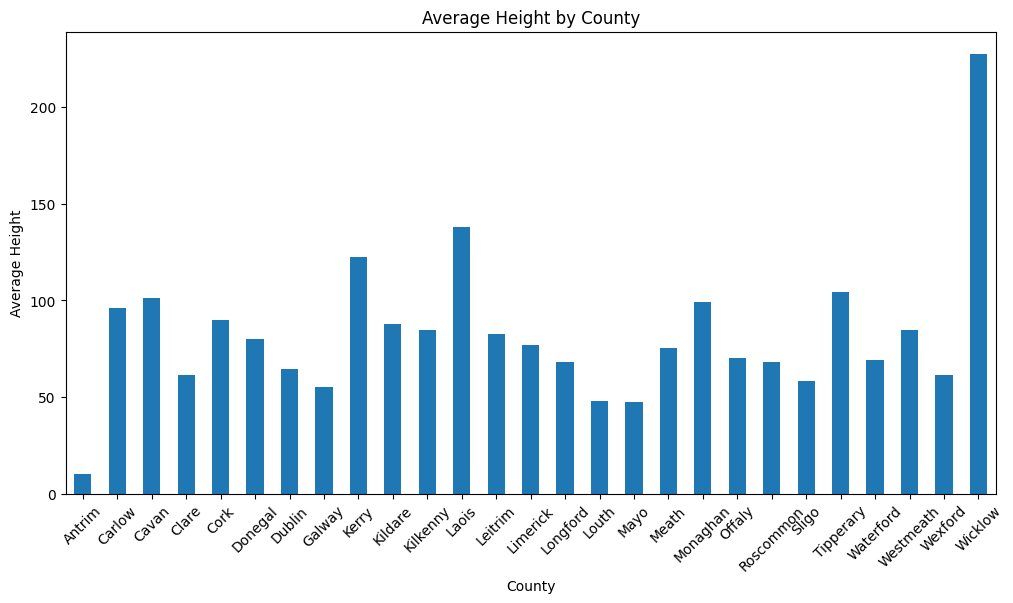

In [12]:
# Calculate the average height by county
average_height_by_county = df.groupby('county')['height(m)'].mean()

# Plot the average height by county
plt.figure(figsize=(12, 6))
average_height_by_county.plot(kind='bar')
plt.title('Average Height by County')
plt.xlabel('County')
plt.ylabel('Average Height')
plt.xticks(rotation=45)
plt.show()